# Variational quantum eigensolver (VQE)

Same Hamiltonian and boundary conditions as `01_exact_diagonalization.ipynb` and `02_nnqs.ipynb`: open-BC TFIM, $J=1$, $h_c=1$. The ground state is approximated with a Hamiltonian Variational Ansatz (HVA) — alternating $ZZ$-entangling and $X$-rotation layers, mirroring the Hamiltonian's own terms — trained with [PennyLane](https://pennylane.ai/) on `lightning.qubit` with adjoint differentiation.

The training logic lives in `src/vqe.py` (`train_vqe`), which also runs headless:

```bash
python -m src.vqe --config configs/vqe_simulation_sweep.yaml       # full L=4..20 sweep, 10 layers, one seed
```

The `L=20` depth scan plotted below is a seed ensemble rather than a single run, so it comes from `src/vqe_seeds.py` instead — 6 field strengths x 5 depths x 8 seeds:

```bash
python -m src.vqe_seeds --config configs/vqe_seed_ensemble.yaml --blocks p4_L20_depth_h_matrix --list
sbatch --array=0-167 scripts/vqe_seeds_array.sh p4_L20_depth_h_matrix    # or --index N to run one point
```

This notebook checks VQE against the exact-diagonalization results from step 1, then digs into an accuracy problem found at `L=20` and asks whether more circuit depth fixes it. The short answer turns out to depend on which `h` you look at, and on separating "how accurate is a typical run" from "how often does the optimizer fail".

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

from src.vqe import train_vqe
from src.nnqs import load_exact_E0

## Single-point sanity check

Train at `L=6, h=1.0` — the critical point — and compare to the exact value.

In [2]:
E0, two_qubit_gates = train_vqe(L=6, h=1.0, J=1.0, n_layers=10, n_steps=600, stepsize=0.1, seed=0)
E_exact = load_exact_E0(6, 1.0, REPO_ROOT / "results" / "exact")
rel_err = abs(E0 - E_exact) / abs(E_exact)

print(f"VQE energy     = {E0:.6f}")
print(f"Exact energy   = {E_exact:.6f}")
print(f"Relative error = {rel_err:.4%}")
print(f"Two-qubit gates = {two_qubit_gates}")
assert rel_err < 0.01, "VQE should be within 1% of exact at L=6, h=1.0"
print("Within tolerance.")

VQE energy     = -7.285122
Exact energy   = -7.296230
Relative error = 0.1522%
Two-qubit gates = 50
Within tolerance.


## Full simulation-track sweep

`L ∈ {4, 6, 8, 10, 12, 16, 20}`, the same 7 `h`-values used in `configs/vqe_phase1_validation.yaml` — smaller than exact/NNQS's 21-point grid, since each `L=20` point costs on the order of an hour (see `configs/vqe_simulation_sweep.yaml`). `L=24` isn't included at all: `default.qubit`'s statevector cost scales like exact diagonalization, and it gets OOM-killed on the local Mac at that size.

This cell loads whatever `results/vqe_sim/{L}/{h}.json` files exist on disk.

In [3]:
results_dir = REPO_ROOT / "results" / "vqe_sim"

records = []
for L_dir in sorted(results_dir.glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        records.append(json.loads(f.read_text()))

print(f"{len(records)} (L, h) points loaded")
worst = max(records, key=lambda r: r["rel_error"])
print(f"Worst relative error: {worst['rel_error']:.4%} at L={worst['L']}, h={worst['h']}")

49 (L, h) points loaded
Worst relative error: 7.4459% at L=20, h=1.2


## VQE vs. exact

Same two-panel layout as `02_nnqs.ipynb`: energy per site (markers over exact lines) on the left, relative error vs. `h` (log scale) on the right.

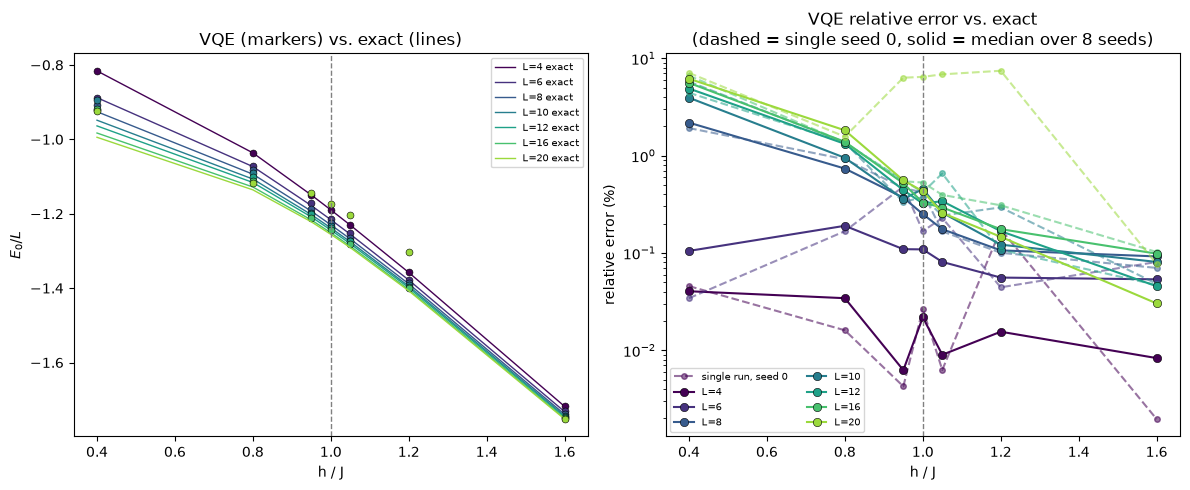

In [4]:
L_values = sorted({r["L"] for r in records})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(L_values)))
for L, color in zip(L_values, colors):
    pts = sorted((r["h"], r["E0"], r["E0_exact"]) for r in records if r["L"] == L)
    h_arr, e_vqe, e_exact = map(np.array, zip(*pts))
    ax1.plot(h_arr, e_exact / L, "-", color=color, linewidth=1, label=f"L={L} exact")
    ax1.plot(h_arr, e_vqe / L, "o", color=color, markersize=5, markeredgecolor="black", markeredgewidth=0.4)

    rel_err = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L)
    h_e, err_e = map(np.array, zip(*rel_err))
    ax2.plot(h_e, err_e * 100, "o--", color=color, markersize=4, alpha=0.55,
             label="single run, seed 0" if L == L_values[0] else None)

    # Same points as medians over 8 seeds, where the ensemble covers them. The
    # single-seed curve above is what this notebook originally reported; the
    # gap between the two is the whole reason the ensemble was run.
    seed_pts = []
    for f in sorted((REPO_ROOT / "results" / "vqe_seeds" / str(L)).glob("*_layers10_seed*.json")):
        d = json.loads(f.read_text())
        seed_pts.append((d["h"], d["rel_error"]))
    if seed_pts:
        by_h = {}
        for h_v, e_v in seed_pts:
            by_h.setdefault(h_v, []).append(e_v)
        hs = sorted(by_h)
        med = [float(np.median(by_h[h_v])) * 100 for h_v in hs]
        ax2.plot(hs, med, "o-", color=color, markersize=6,
                 markeredgecolor="black", markeredgewidth=0.4,
                 label=f"L={L}")

ax1.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("h / J")
ax1.set_ylabel("$E_0 / L$")
ax1.set_title("VQE (markers) vs. exact (lines)")
ax1.legend(fontsize=7)

ax2.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.set_yscale("log")
ax2.set_xlabel("h / J")
ax2.set_ylabel("relative error (%)")
ax2.set_title("VQE relative error vs. exact\n(dashed = single seed 0, solid = median over 8 seeds)")
ax2.legend(fontsize=7, ncol=2)

fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_vs_exact.png", dpi=150)
plt.show()

## The L=20 problem — as it first appeared

The ferromagnetic end is already poor well before `L=20`: at `h=0.4` the 10-layer median error is 2.18% at `L=8` and 5.59% by `L=16`. Away from `h <= 0.8`, though, the `L <= 16` medians all stay under 0.55%. Individual runs go higher — the worst single seed at `L <= 16` is 1.56% — so the bound is on the typical run, not on every run.

At `L=20` a single run at `seed=0` looks far worse right across the grid — 6-7% at most `h`, with only `h=0.8` and the deep-paramagnetic `h=1.6` escaping:

In [5]:
l20 = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == 20)
for h, err in l20:
    print(f"h={h:<5} rel_err={err:.4%}")

h=0.4   rel_err=7.0793%
h=0.8   rel_err=1.5667%
h=0.95  rel_err=6.3148%
h=1.0   rel_err=6.4453%
h=1.05  rel_err=6.8401%
h=1.2   rel_err=7.4459%
h=1.6   rel_err=0.0769%


Taken at face value this looks like two different mechanisms:

- **Near h_c (h=0.95-1.2):** the HVA's nearest-neighbour gates spread correlations only about one site per layer, so a fixed 10-layer circuit can't span the diverging correlation length once the chain (`L=20`) outgrows the circuit's reach.
- **h=0.4 (deep ferromagnetic):** the true ground state there is GHZ-like — a genuine ansatz-*expressiveness* limit, not a correlation-length one.

**Only the second survives.** Every number above comes from one optimization run at `seed=0`, and the HVA objective is not convex, so a different initialization can land in a different minimum. Repeating each point over 8 seeds — below — shows that near `h_c` those 6-7% figures are not the typical result. They are the minority of runs in which the optimizer fails outright.

## Does more depth fix it?

The scan below covers `L=20` at six `h` values and five circuit depths, 8 seeds each — 168 runs in total (`configs/vqe_seed_ensemble.yaml`, block `p4_L20_depth_h_matrix`).

Two questions are worth keeping apart, because they turn out to move independently: whether the **typical run** gets more accurate, and whether the optimizer **fails** less often. A single mean would blur them together.

These runs use `lightning.qubit` with adjoint differentiation rather than `default.qubit`'s backprop — backprop keeps a statevector per gate, so its memory grows with circuit depth and runs out of room at these sizes, while adjoint differentiation stays flat in depth.

h      10L               16L               20L               24L               30L               
0.4    6.16% [8/8]       4.45% [8/8]       3.51% [8/8]       2.90% [8/8]       2.59% [8/8]       
0.8    1.82% [8/8]       1.26% [7/8]       1.15% [5/8]       1.05% [4/8]       1.01% [4/8]       
0.95   0.56% [1/8]       0.48% [0/8]       0.45% [1/8]       1.35% [4/8]       0.70% [1/8]       
1.0    0.43% [2/8]       0.39% [0/8]       0.40% [1/8]       0.58% [2/8]       0.29% [0/8]       
1.05   0.26% [2/8]       0.35% [1/8]       0.18% [1/8]       0.39% [2/8]       0.33% [0/8]       
1.2    0.15% [1/8]       0.44% [1/8]       0.25% [2/8]       0.38% [3/8]       0.28% [2/8]       


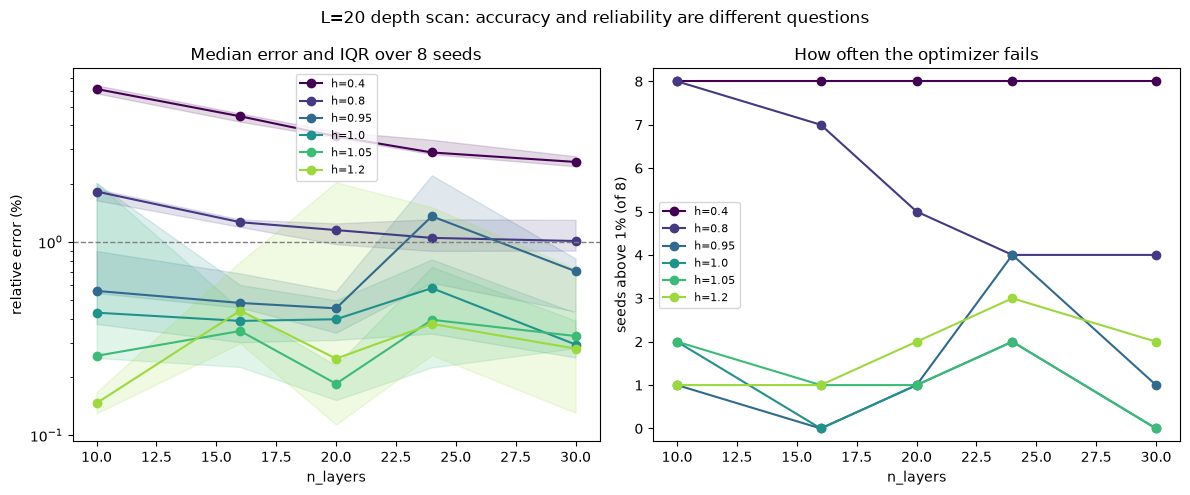

In [6]:
# Depth scan at L=20, over 8 seeds per point.
#
# Each point is 8 independent optimizations rather than one. That matters here
# more than anywhere else in the project: near h_c the seeds do not form a
# single cluster, so a one-run number can land in either of two very different
# places. Medians and the interquartile band describe the typical run; the
# count of seeds above 1% describes how often the optimizer fails outright.
seed_dir = REPO_ROOT / "results" / "vqe_seeds" / "20"

DEPTHS = [10, 16, 20, 24, 30]
H_VALUES = [0.4, 0.8, 0.95, 1.0, 1.05, 1.2]
FAIL_THRESHOLD = 0.01  # the project's existing 1% tolerance


def depth_scan_stats(h, n_layers):
    """Median, quartiles and failure count over the seeds at one (h, n_layers)."""
    errs = sorted(
        json.loads(p.read_text())["rel_error"]
        for p in seed_dir.glob(f"{h:.3f}_layers{n_layers}_seed*.json")
    )
    if not errs:
        return None
    return {
        "median": float(np.median(errs)),
        "q1": float(np.percentile(errs, 25)),
        "q3": float(np.percentile(errs, 75)),
        "n_failed": sum(e > FAIL_THRESHOLD for e in errs),
        "n": len(errs),
    }


print(f"{'h':<7}" + "".join(f"{str(d) + 'L':<18}" for d in DEPTHS))
for h in H_VALUES:
    row = f"{h:<7}"
    for d in DEPTHS:
        s = depth_scan_stats(h, d)
        row += "—".ljust(18) if s is None else f"{s['median']*100:.2f}% [{s['n_failed']}/{s['n']}]".ljust(18)
    print(row)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(H_VALUES)))
for h, color in zip(H_VALUES, colors):
    stats = [(d, depth_scan_stats(h, d)) for d in DEPTHS]
    stats = [(d, s) for d, s in stats if s]
    d_arr = np.array([d for d, _ in stats])
    med = np.array([s["median"] for _, s in stats]) * 100
    q1 = np.array([s["q1"] for _, s in stats]) * 100
    q3 = np.array([s["q3"] for _, s in stats]) * 100
    ax1.plot(d_arr, med, "o-", color=color, label=f"h={h}")
    ax1.fill_between(d_arr, q1, q3, color=color, alpha=0.15)
    ax2.plot(d_arr, [s["n_failed"] for _, s in stats], "o-", color=color, label=f"h={h}")

ax1.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_yscale("log")
ax1.set_xlabel("n_layers")
ax1.set_ylabel("relative error (%)")
ax1.set_title("Median error and IQR over 8 seeds")
ax1.legend(fontsize=8)

ax2.set_xlabel("n_layers")
ax2.set_ylabel("seeds above 1% (of 8)")
ax2.set_title("How often the optimizer fails")
ax2.set_ylim(-0.3, 8.3)
ax2.legend(fontsize=8)

fig.suptitle("L=20 depth scan: accuracy and reliability are different questions")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_L20_depth_scan.png", dpi=150)
plt.show()

The two regimes behave completely differently, and not the way the single-seed numbers suggested.

**Ferromagnetic (`h <= 0.8`) — depth is the only thing that helps.** At `h=0.4` the median falls 6.16% -> 4.45% -> 3.51% -> 2.90% -> 2.59% from 10 to 30 layers, monotonically. The step from 16 to 24 layers is 3.1 standard errors, so it is a real improvement rather than scatter; 24 to 30 layers is 1.9 and not resolvable on 8 seeds. Error is still falling at 30 layers, so there is no plateau here to point at. But all 8 seeds stay above 1% at every depth, so depth improves the answer without ever making it good. That fits the GHZ-expressiveness limit: an HVA layer shares the same two parameters across the whole chain, and more of the same layer does not resolve that.

**Near h_c (`h >= 0.95`) — depth does nothing, because nothing is broken.** The medians stay between 0.15% and 0.7% across a threefold change in depth, with no trend. At `h=1.0` the nominal 10-to-16-layer improvement is 1.5 standard errors — indistinguishable from no change, and driven by the failed seeds rather than by the converged ones. 10 layers already reaches a few tenths of a percent whenever the optimizer converges. What varies is *reliability*: one or two seeds in eight fail outright and land near 6-8%, and the `seed=0` values quoted earlier are exactly those failures.

So the near-critical circuit-reach explanation is not supported by the ensemble. A correlation-length limit would appear as a systematic accuracy ceiling that every seed runs into; instead six of eight seeds converge to a few tenths of a percent and the remainder fail completely. That is an optimizer-landscape signature, not a circuit-depth one — and it means the earlier reading of this figure had the two mechanisms the wrong way round.

One oddity worth recording rather than explaining: at 24 layers the near-critical failure count rises to 11 of 32 runs, against 2 of 32 at 16 layers and 3 of 32 at 30. Unlike the `seed=0` failures these are spread over seven different seeds, so it is not one unlucky initialization — but it is non-monotonic in depth, which nothing here accounts for. It needs more seeds before it means anything.

## Reaching L=24

The simulator track used to stop at `L=20` while exact diagonalization and NNQS both reached `L=24`. That was a memory limit rather than a physics one: `default.qubit`'s backprop keeps a statevector per gate, so its footprint grows with circuit depth and `L=24` ran out of room. Adjoint differentiation keeps memory at O(2^L) regardless of depth — measured at 2.0 GB for `L=24` — so the constraint no longer applies.

`L=24` is run at three field strengths spanning the phase diagram rather than the full seven, because each run costs 6.5–19.75 h on one core. 8 seeds each, same 10 layers and 600 steps as the rest of the sweep, so the points below sit on the same footing as every other `L`.

Median relative error % over 8 seeds, 10 layers  [seeds above 1% / n]
L    h=0.4               h=1.0               h=1.6               
4    0.040 [0/8]         0.022 [0/8]         0.008 [0/8]         
6    0.105 [1/8]         0.109 [0/8]         0.054 [0/8]         
8    2.181 [8/8]         0.251 [0/8]         0.092 [0/8]         
10   3.934 [8/8]         0.454 [2/8]         0.081 [0/8]         
12   4.889 [8/8]         0.322 [0/8]         0.045 [0/8]         
16   5.594 [8/8]         0.328 [0/8]         0.098 [0/8]         
20   6.164 [8/8]         0.430 [2/8]         0.030 [0/8]         
24   6.071 [8/8]         0.626 [3/8]         0.081 [0/8]         


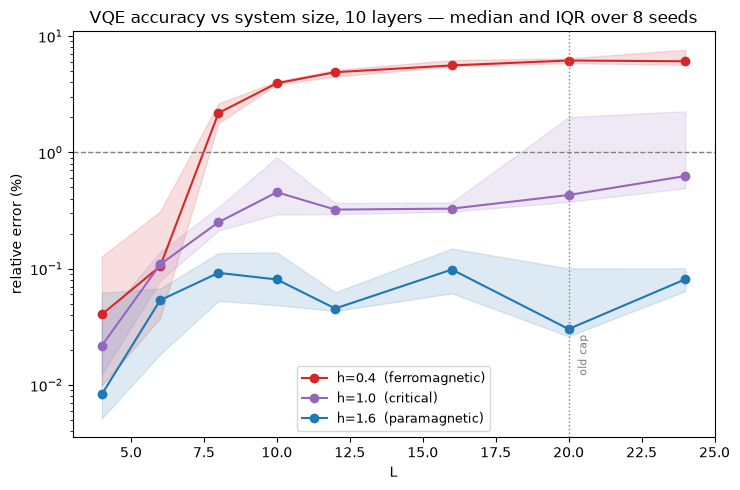

In [7]:
# L=24 — the size the simulator track previously stopped short of.
#
# The old cap came from default.qubit's backprop storing a statevector per gate,
# so memory grew with circuit depth. Adjoint differentiation is O(2^L) regardless
# of depth — measured at 2.0 GB here — so the cap no longer applies.
#
# Plotted against L from 4 to 24 so the three regimes can be compared on equal
# footing: every point below is a median over 8 seeds, at 10 layers.
seed_dir = REPO_ROOT / "results" / "vqe_seeds"

L_VALUES = [4, 6, 8, 10, 12, 16, 20, 24]
H_TRACKED = [0.4, 1.0, 1.6]


def seed_stats(L, h, n_layers=10):
    """Median, quartiles and failure count over the seeds at one (L, h)."""
    errs = sorted(
        json.loads(p.read_text())["rel_error"]
        for p in (seed_dir / str(L)).glob(f"{h:.3f}_layers{n_layers}_seed*.json")
    )
    if not errs:
        return None
    return {"median": float(np.median(errs)), "q1": float(np.percentile(errs, 25)),
            "q3": float(np.percentile(errs, 75)), "n": len(errs),
            "n_failed": sum(e > 0.01 for e in errs)}


print("Median relative error % over 8 seeds, 10 layers  [seeds above 1% / n]")
print(f"{'L':<5}" + "".join(f"{'h=' + str(h):<20}" for h in H_TRACKED))
for L in L_VALUES:
    row = f"{L:<5}"
    for h in H_TRACKED:
        s = seed_stats(L, h)
        row += "—".ljust(20) if s is None else f"{s['median']*100:.3f} [{s['n_failed']}/{s['n']}]".ljust(20)
    print(row)

fig, ax = plt.subplots(figsize=(7.5, 5))
colors = {0.4: "tab:red", 1.0: "tab:purple", 1.6: "tab:blue"}
labels = {0.4: "h=0.4  (ferromagnetic)", 1.0: "h=1.0  (critical)", 1.6: "h=1.6  (paramagnetic)"}
for h in H_TRACKED:
    pts = [(L, seed_stats(L, h)) for L in L_VALUES]
    pts = [(L, s) for L, s in pts if s]
    L_arr = np.array([L for L, _ in pts])
    med = np.array([s["median"] for _, s in pts]) * 100
    q1 = np.array([s["q1"] for _, s in pts]) * 100
    q3 = np.array([s["q3"] for _, s in pts]) * 100
    ax.plot(L_arr, med, "o-", color=colors[h], label=labels[h])
    ax.fill_between(L_arr, q1, q3, color=colors[h], alpha=0.15)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.axvline(20, color="gray", linestyle=":", linewidth=1)
ax.text(20.3, 0.012, "old cap", fontsize=8, color="gray", rotation=90, va="bottom")
ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("relative error (%)")
ax.set_title("VQE accuracy vs system size, 10 layers — median and IQR over 8 seeds")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_error_vs_L_seeds.png", dpi=150)
plt.show()

Two things stand out, and the first is not what the `L≤16` trend predicted.

**The ferromagnetic error saturates — it does not keep growing with L.** At `h=0.4` the median climbs steeply from `L=6` to `L=10` (0.105% → 3.93%), then flattens: 4.89, 5.59, 6.16, and 6.07% at `L=24`. `L=20` and `L=24` are indistinguishable — 6.164% against 6.071%, with the distributions fully overlapping (`L=20` spans 5.75–11.21%, `L=24` spans 5.42–10.62%). Read from `L≤16` alone the curve looks like unbounded degradation; it is not, it is an approach to a ceiling.

That fits the expressiveness reading rather than a correlation-length one. A translationally-symmetric HVA layer carries the same two parameters across the whole chain, so at fixed depth it can only represent a fixed amount of structure — and once the chain is long enough to exhaust that, making it longer costs nothing more. A correlation-length limit would keep worsening as the chain grows.

**Near h_c the failures are the whole story.** The `h=1.0` median stays between 0.02% and 0.63% at every `L`, so accuracy is essentially flat in system size. What changes is how often the optimizer fails: 0/8 seeds above 1% at `L=4` through `L=8`, then 2/8 at `L=10`, 0/8 at `L=12` and `L=16`, 2/8 at `L=20`, 3/8 at `L=24`. The widening interquartile band at large `L` in the figure is those failures, not a drift in the typical run.

`h=1.6` never fails and never exceeds 0.17% anywhere, including `L=24`.

A caveat on reproducing any single number here: two `L=24` runs at identical seed and configuration on different cluster nodes gave E₀ = −30.041607 and −30.041632, differing at 2.5e-5. That is far above floating-point noise on a single operation — 600 optimizer steps amplify a last-digit difference in the early gradients. These results are reproducible in distribution, not in value, which is the reason every number in this section is quoted as a median over seeds rather than as a run.